In [19]:
import pandas as pd
import numpy as np
import scipy as sp

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats.mstats import winsorize


pd.set_option("display.max_columns", None)
pd.reset_option("display.max_rows")
pd.set_option('future.no_silent_downcasting', True)

import sys
import os
sys.path.append(os.path.abspath("../../.."))
from utils.categorical_qcut import categorical_qcut

from tqdm import tqdm
tqdm.pandas()

### Helpers

In [20]:
from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

In [21]:
def remove_indexname(series): # removes index name
    series.index.name = None
    series.name = None
    return series.to_string()

# STUDY 1: European Countries

## a. Method:
i. Validated inventories: Numeracy, Graph Literacy, Combination of both ( = naive Risk Literacy)

ii. Outcomes: Income, Wealth

---

IMPORTANT ASSUMPTIONS:
1. No wealth windsorization
---

### Data preparation and sample stats

In [36]:
import_folder_path = rf"../europe"
df00 = pd.read_pickle(rf"{import_folder_path}/Europe_dataset_scoredOnly.pkl")

In [37]:
# Any additional data wrangle:
# NAIVE RL caluclation
df00["Naive_RL_6"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"]
df00["Naive_RL_%"] = df00["Naive_RL_6"] / 6 * 100


In [38]:
# print("Total Observations:", df00["Q1"].count())

print(f'\nGender:\n{remove_indexname(df00["gender_text"].value_counts())}')
print('-' * 100)
print(f'ISCED:\n{remove_indexname(df00["isced"].value_counts().sort_index())}')
print('-' * 100)
# print(f'Income:\n{remove_indexname(df00["income_text"].value_counts().sort_index())}')
print(f'\nIncome_code:\n{remove_indexname(df00["income"].value_counts().sort_index())}')
print('-' * 100)
print(f'Countries:\n{remove_indexname(df00["country_text"].value_counts())}')
print(f'\nCountries_code:\n{remove_indexname(df00["country"].value_counts())}')
print('-' * 100)

euro = df00.copy()
# print(f'\nOccupation:\n{remove_indexname(df0["Q4a"].value_counts())}')
# print(f'\nEducation:\n{remove_indexname(df0["Q3"].value_counts())}')


Gender:
Female    2000
Male      1906
----------------------------------------------------------------------------------------------------
ISCED:
1    1197
2    1795
3     914
----------------------------------------------------------------------------------------------------

Income_code:
-1.0    535
 1.0    853
 2.0    785
 3.0    654
 4.0    480
 5.0    359
 6.0    240
----------------------------------------------------------------------------------------------------
Countries:
France     677
Poland     656
UK         652
Spain      646
Sweden     643
Germany    632

Countries_code:
12.0    677
21.0    656
9.0     652
10.0    646
29.0    643
7.0     632
----------------------------------------------------------------------------------------------------


---

## b. Results

### i. Descriptive Statistics per Country

#### 1. Frequency distribution of numeracy scores (sum of correct responses)

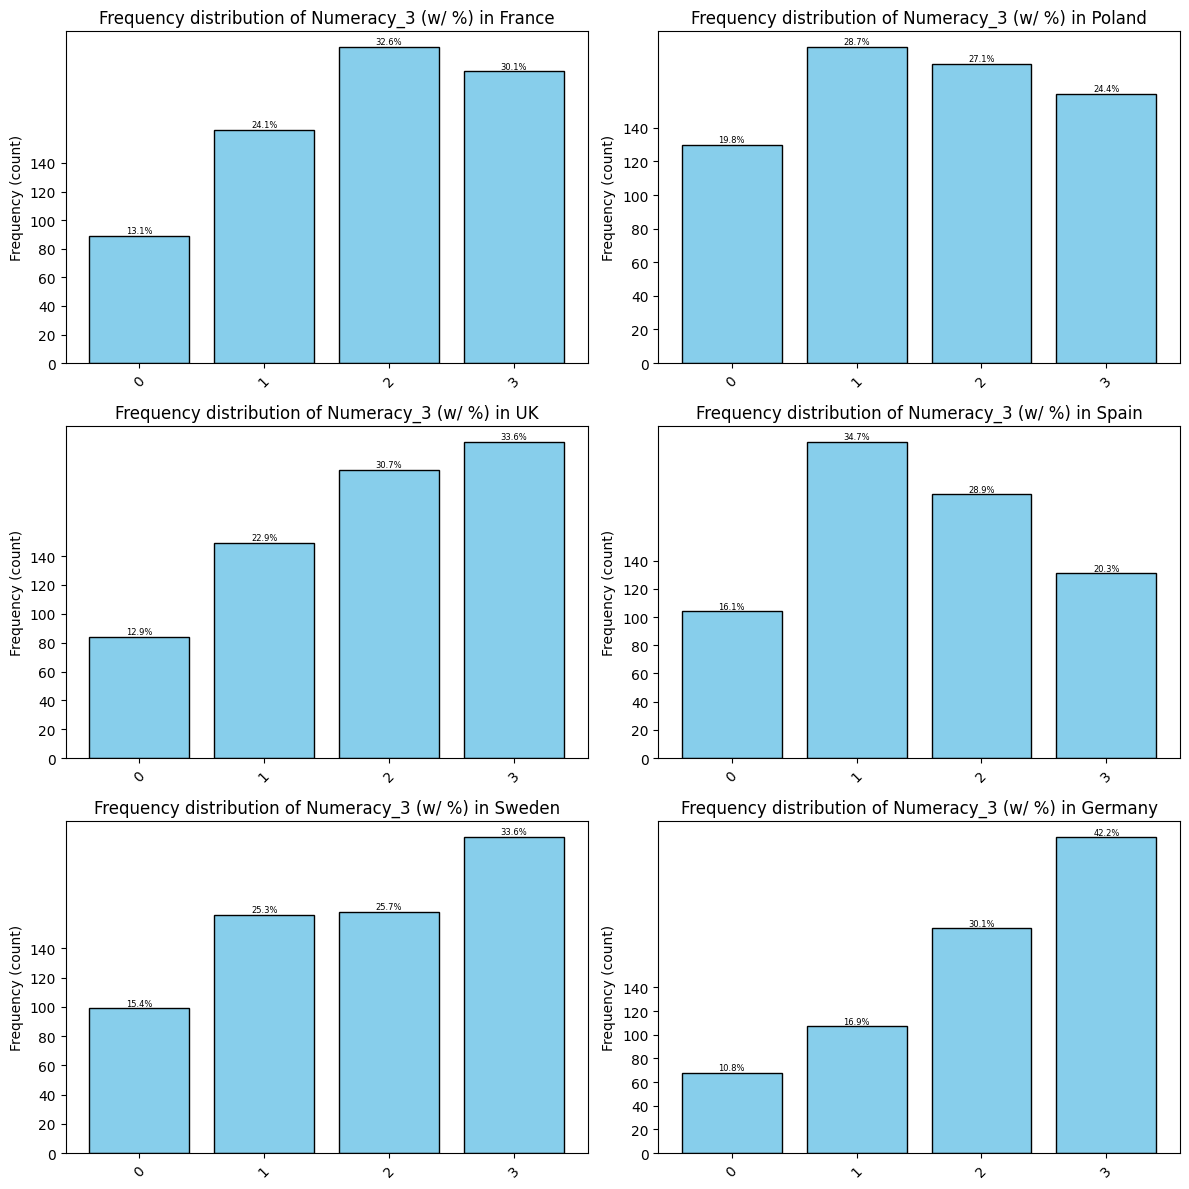

In [39]:
fig, axes = plt.subplots(3, 2, figsize = [12, 12])
axes = axes.flatten()

countries = euro["country_text"].value_counts().index.to_list()

for i, country in enumerate(countries):
    sample = euro.loc[euro["country_text"] == country, "Numeracy_3"].value_counts().sort_index()
    x = sample.index
    y = sample.values
    total = sample.sum() 
    
    axes[i].bar(x, y, color="skyblue", edgecolor='black')
    
    for j, value in zip(sample.index, sample.values):
        axes[i].text(j, value + 0.5, f"{value/total * 100:.1f}%", ha = "center", va = "bottom", fontsize=6, color="black")
    
    axes[i].set_yticks(np.arange(0, 151, step = 20))
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(x, rotation = 45, ha = "center")
    
    axes[i].set_ylabel(f"Frequency (count)")
    axes[i].set_title(f"Frequency distribution of Numeracy_3 (w/ %) in {country}")

plt.tight_layout()
plt.show()

#### 2. Frequency distribution of graph literacy scores (sum of correct responses)

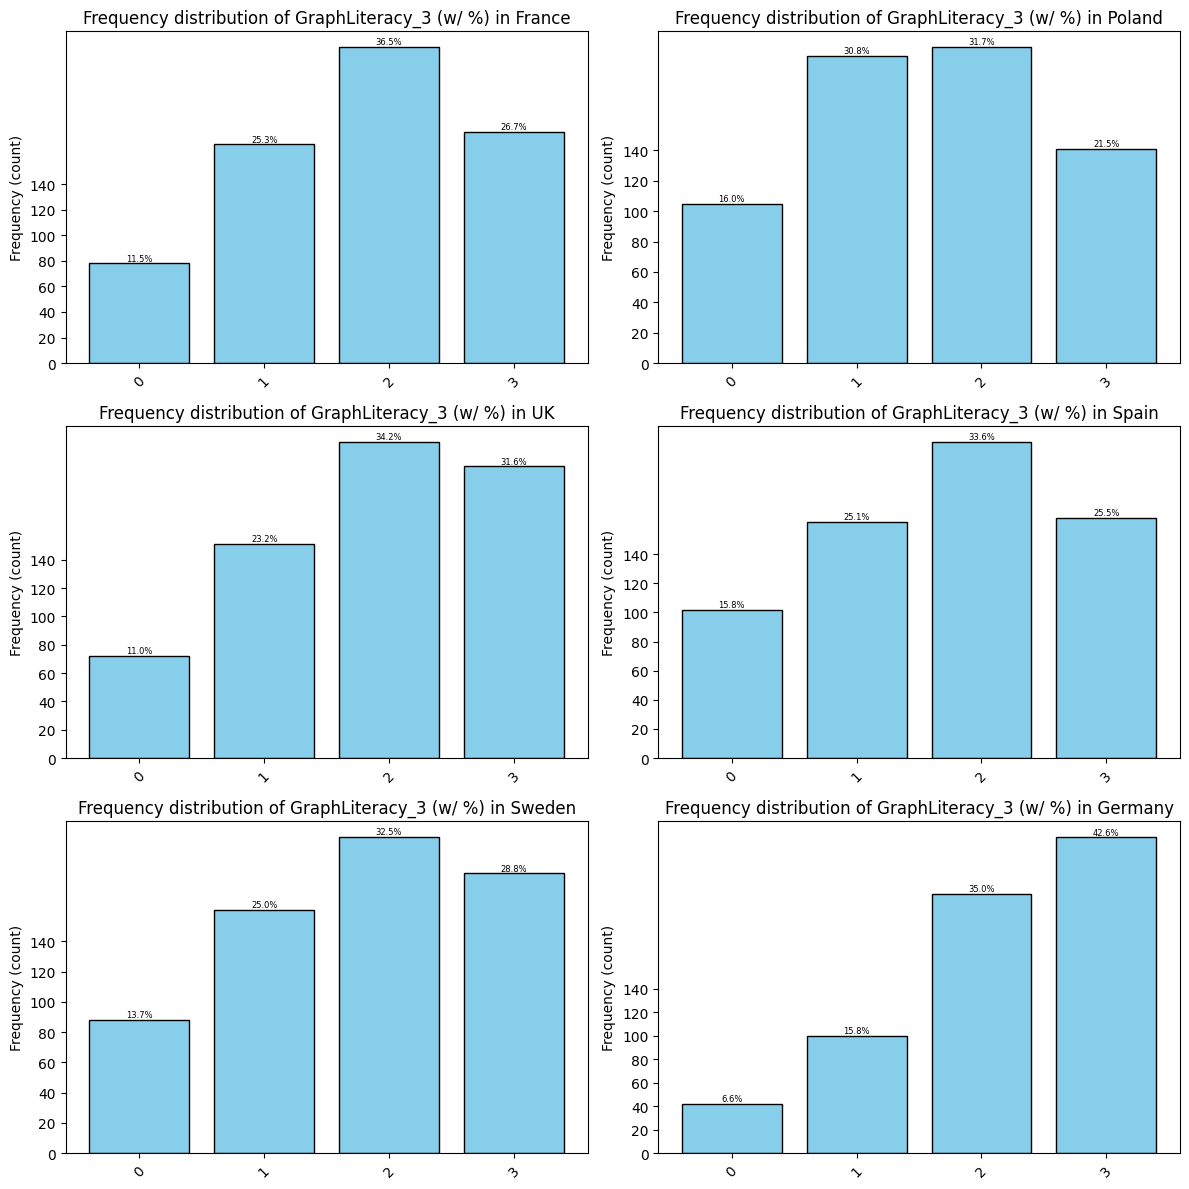

In [40]:
fig, axes = plt.subplots(3, 2, figsize = [12, 12])
axes = axes.flatten()

countries = euro["country_text"].value_counts().index.to_list()

for i, country in enumerate(countries):
    sample = euro.loc[euro["country_text"] == country, "GraphLiteracy_3"].value_counts().sort_index()
    x = sample.index
    y = sample.values
    total = sample.sum() 
    
    axes[i].bar(x, y, color="skyblue", edgecolor='black')
    
    for j, value in zip(sample.index, sample.values):
        axes[i].text(j, value + 0.5, f"{value/total * 100:.1f}%", ha = "center", va = "bottom", fontsize=6, color="black")
    
    axes[i].set_yticks(np.arange(0, 151, step = 20))
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(x, rotation = 45, ha = "center")
    
    axes[i].set_ylabel(f"Frequency (count)")
    axes[i].set_title(f"Frequency distribution of GraphLiteracy_3 (w/ %) in {country}")

plt.tight_layout()
plt.show()

### ii. Descriptive statistics (Europe=6 countries)

#### Show the relationship between sum of numeracy+graph literacy and wealth [all age]stratified by education

In [41]:
isced = euro["isced"].unique()

In [42]:
euro["Naive_RL_%"]

0       100.000000
1        83.333333
2        33.333333
3        83.333333
4       100.000000
           ...    
3901     16.666667
3902    100.000000
3903     33.333333
3904     83.333333
3905     16.666667
Name: Naive_RL_%, Length: 3906, dtype: float64

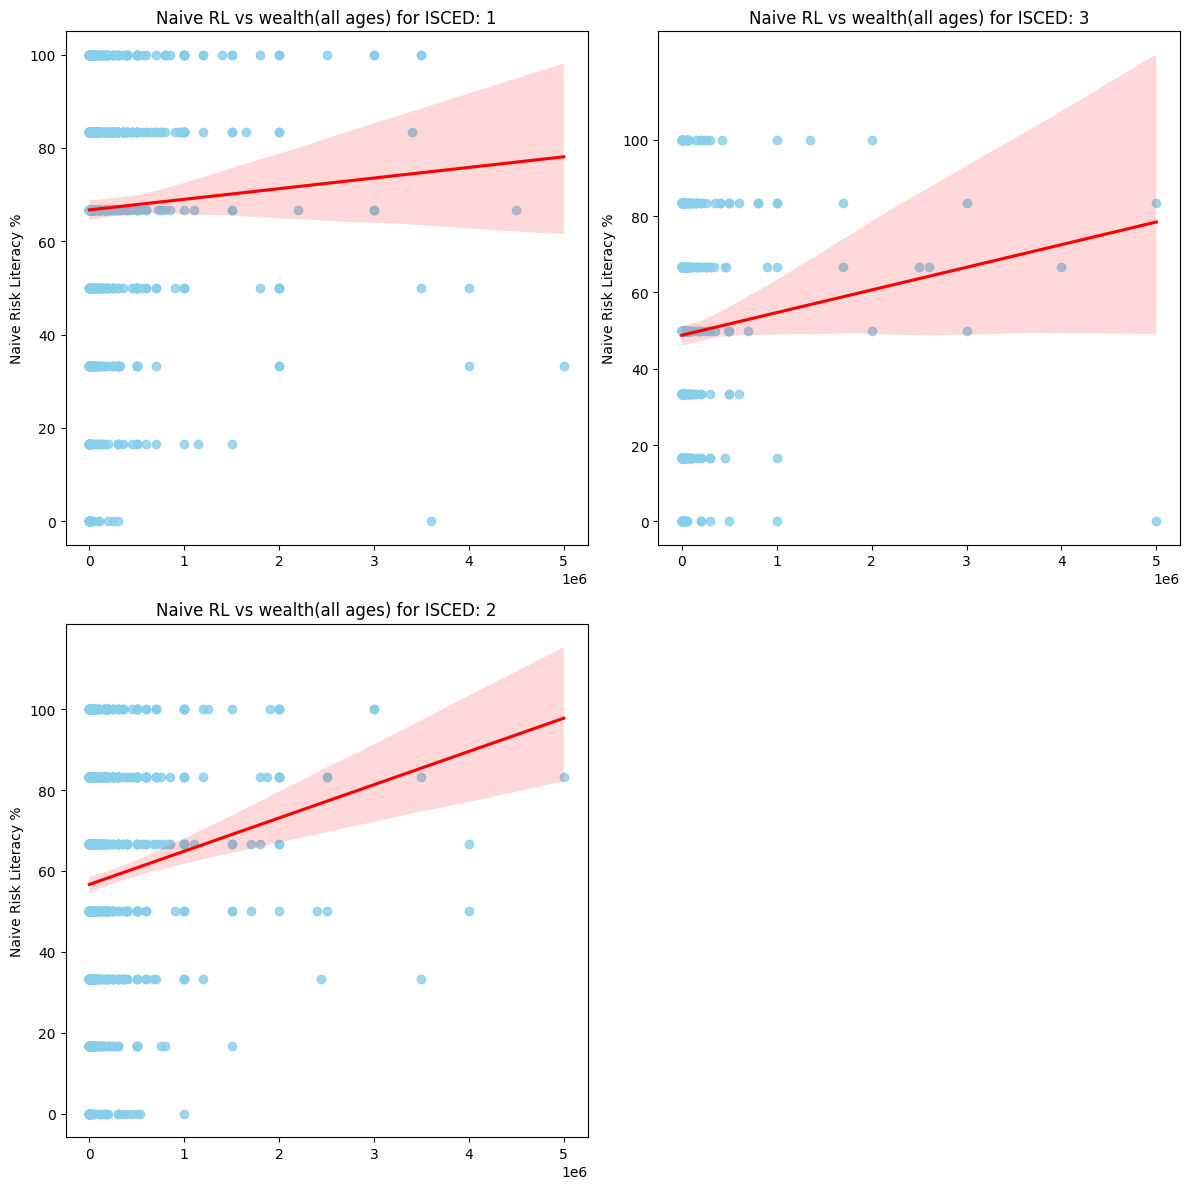

In [59]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = euro["isced"].unique()

for i, edu in enumerate(isced):
    sample = euro.loc[(euro["isced"] == edu) & (euro["wealth"] != -1)].copy()
    x = sample["wealth"].values
    y = sample["Naive_RL_%"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 101, step = 20))
    
    axes[i].set_ylabel(f"Naive Risk Literacy %")
    axes[i].set_title(f"Naive RL vs wealth(all ages) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

Show the relationship between sum of numeracy+graph literacy and income [31-59y] stratified by education

In [63]:
euro["age_rec"].value_counts()

age_rec
3    1749
2    1137
4    1020
Name: count, dtype: int64

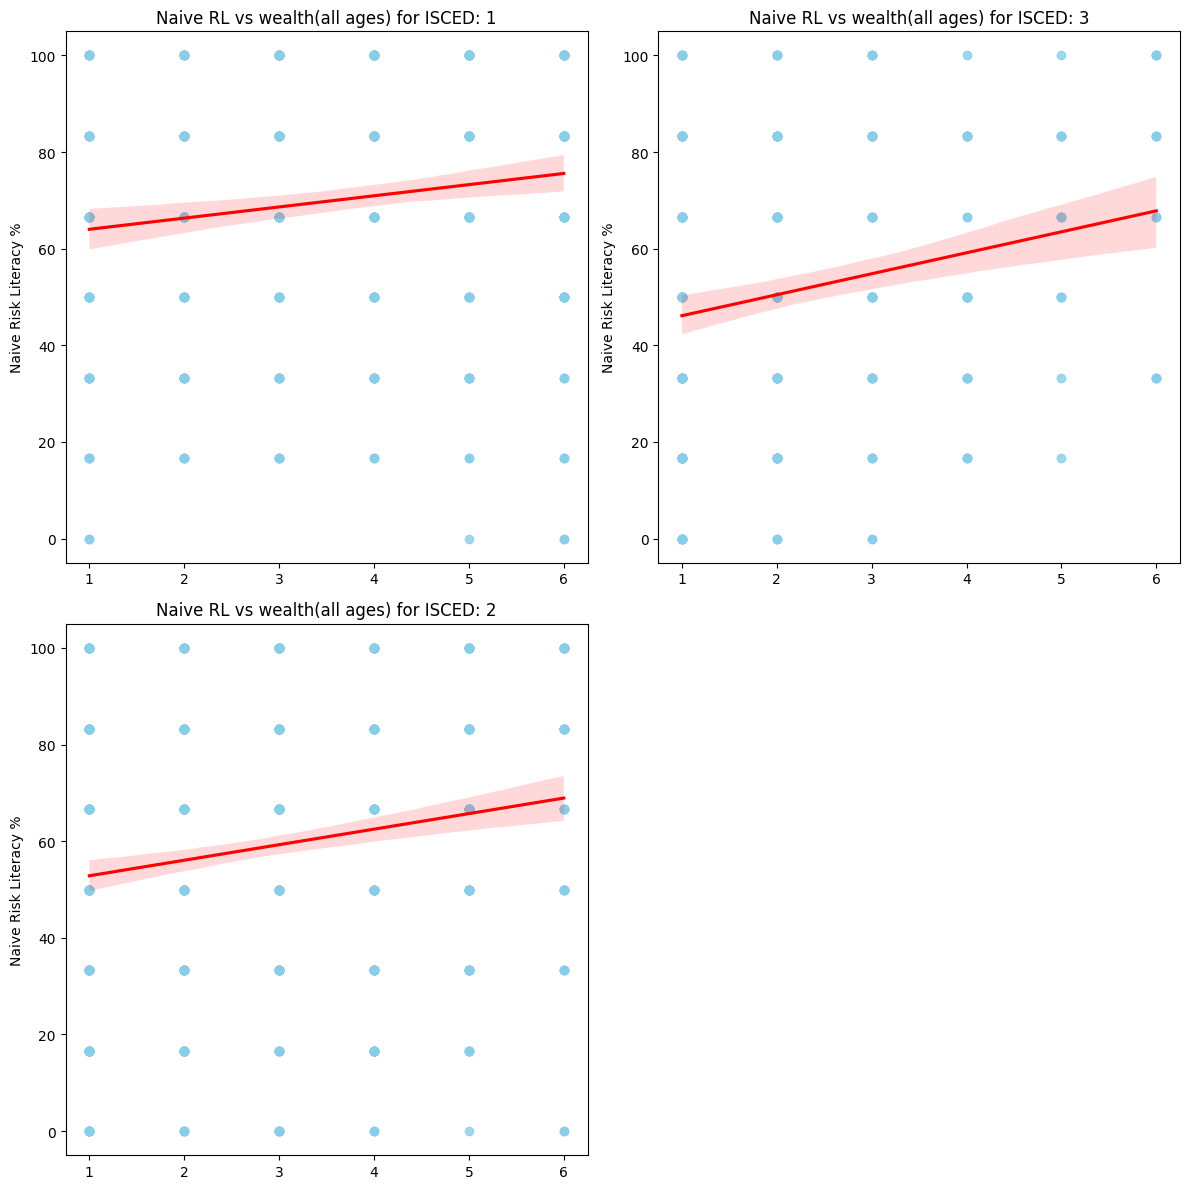

In [64]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = euro["isced"].unique()

for i, edu in enumerate(isced):
    sample = euro.loc[
        (euro["isced"] == edu)
        & (euro["income"] != -1)
        & (euro["age_rec"] == 3)].copy()
    
    x = sample["income"].values
    y = sample["Naive_RL_%"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 101, step = 20))
    
    axes[i].set_ylabel(f"Naive Risk Literacy %")
    axes[i].set_title(f"Naive RL vs wealth(all ages) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

### iii. Appendix

#### Correlation matrix between numeracy, graph literacy, demographics

In [74]:
cols = ["Numeracy_3", "GraphLiteracy_3","age", "isced"]
corr_matrix = euro[cols].corr()
print(corr_matrix)

                 Numeracy_3  GraphLiteracy_3       age     isced
Numeracy_3         1.000000         0.424088  0.023587 -0.229742
GraphLiteracy_3    0.424088         1.000000  0.002299 -0.163469
age                0.023587         0.002299  1.000000  0.107995
isced             -0.229742        -0.163469  0.107995  1.000000


### iv. Inference statistics (Europe=6 countries)

#### Numeracy: Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort)

In [75]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["Numeracy_3", "age"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     31.30
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           3.96e-14
Time:                        09:15:47   Log-Likelihood:                -31900.
No. Observations:                2187   AIC:                         6.381e+04
Df Residuals:                    2184   BIC:                         6.382e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.246e+04   4.09e+04     -1.037      0.3

##### Predicting wealth: income when analysing wealth

In [76]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["Numeracy_3", "age", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     60.26
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.00e-37
Time:                        09:15:48   Log-Likelihood:                -31844.
No. Observations:                2187   AIC:                         6.370e+04
Df Residuals:                    2183   BIC:                         6.372e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.065e+05   4.27e+04     -4.831      0.0

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort)

In [77]:
data = euro.loc[euro["income"] != -1].copy()

model = sm.OLS(data["income"], sm.add_constant(data[["Numeracy_3", "age"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     63.46
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           8.79e-28
Time:                        09:15:50   Log-Likelihood:                -6214.1
No. Observations:                3371   AIC:                         1.243e+04
Df Residuals:                    3368   BIC:                         1.245e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2787      0.096     23.850      0.0

#### Graph Literacy: Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort)

In [78]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["GraphLiteracy_3", "age"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     12.96
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.53e-06
Time:                        09:15:52   Log-Likelihood:                -31918.
No. Observations:                2187   AIC:                         6.384e+04
Df Residuals:                    2184   BIC:                         6.386e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.404e+04   4.17e+04     

##### Predicting wealth: income when analysing wealth

In [79]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"].abs(), sm.add_constant(data[["GraphLiteracy_3", "age", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     54.48
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           5.89e-34
Time:                        09:15:53   Log-Likelihood:                -31852.
No. Observations:                2187   AIC:                         6.371e+04
Df Residuals:                    2183   BIC:                         6.374e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.747e+05   4.39e+04     

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort)

In [80]:
data = euro.loc[euro["income"] != -1].copy()

model = sm.OLS(data["income"].abs(), sm.add_constant(data[["GraphLiteracy_3", "age"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     17.66
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.35e-08
Time:                        09:15:55   Log-Likelihood:                -6258.9
No. Observations:                3371   AIC:                         1.252e+04
Df Residuals:                    3368   BIC:                         1.254e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.4744      0.099     

### iv. Exploratory analysis: Naive RL

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort)

In [ ]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["Naive_RL_6", "age"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     12.96
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.53e-06
Time:                        09:15:52   Log-Likelihood:                -31918.
No. Observations:                2187   AIC:                         6.384e+04
Df Residuals:                    2184   BIC:                         6.386e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.404e+04   4.17e+04     

##### Predicting wealth: income when analysing wealth

In [ ]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"].abs(), sm.add_constant(data[["Naive_RL_6", "age", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     54.48
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           5.89e-34
Time:                        09:15:53   Log-Likelihood:                -31852.
No. Observations:                2187   AIC:                         6.371e+04
Df Residuals:                    2183   BIC:                         6.374e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.747e+05   4.39e+04     

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort)

In [ ]:
data = euro.loc[euro["income"] != -1].copy()

model = sm.OLS(data["income"].abs(), sm.add_constant(data[["Naive_RL_6", "age"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     17.66
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.35e-08
Time:                        09:15:55   Log-Likelihood:                -6258.9
No. Observations:                3371   AIC:                         1.252e+04
Df Residuals:                    3368   BIC:                         1.254e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.4744      0.099     

---

---

# 2. Study 2: Dynata 1 (India)

### a. What is this study adding?

 i. Representativeness in terms of year 2025

ii. Representativeness in terms of global south

iii. Exploration of the illusion of certainty – Creating a measure with

iv. Indicate mechanisms of how wealth generation might be affected by risk literacy(explanation of the relationship with wealth)


### b. Methods

---

IMPORTANT ASSUMPTIONS:
1. Wealth windsorization @ 1%, both ends
---

### Data preparation and sample stats

In [ ]:
import_folder_path = rf"../india_dynata"
df00 = pd.read_pickle(rf"{import_folder_path}/India_Dynata_dataset_scoredOnly.pkl")


In [ ]:
# Any additional data wrangle:
# NAIVE RL caluclation
df00["Naive_RL_6"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"]
df00["Naive_RL_%"] = df00["Naive_RL_6"] / 6 * 100

# Windorized wealth at 1% both end
winsorized_wealth = winsorize_output(df00, "wealth", [0.01, 0.01])
# Using winsorised wealth as wealth
df00["wealth"] = winsorized_wealth

In [ ]:
# print("Total Observations:", df00["Q1"].count())

print(f'\nGender:\n{remove_indexname(df00["gender_text"].value_counts())}')
print('-' * 100)
print(f'ISCED:\n{remove_indexname(df00["isced"].value_counts().sort_index())}')
print('-' * 100)
# print(f'Income:\n{remove_indexname(df00["income_text"].value_counts().sort_index())}')
print(f'\nIncome_code:\n{remove_indexname(df00["income"].value_counts().sort_index())}')
print('-' * 100)
print(f'Countries:\n{remove_indexname(df00["country_text"].value_counts())}')
print(f'\nCountries_code:\n{remove_indexname(df00["country"].value_counts())}')
print('-' * 100)

euro = df00.copy()
# print(f'\nOccupation:\n{remove_indexname(df0["Q4a"].value_counts())}')
# print(f'\nEducation:\n{remove_indexname(df0["Q3"].value_counts())}')


Gender:
Female    2000
Male      1906
----------------------------------------------------------------------------------------------------
ISCED:
1    1197
2    1795
3     914
----------------------------------------------------------------------------------------------------

Income_code:
-1.0    535
 1.0    853
 2.0    785
 3.0    654
 4.0    480
 5.0    359
 6.0    240
----------------------------------------------------------------------------------------------------
Countries:
France     677
Poland     656
UK         652
Spain      646
Sweden     643
Germany    632

Countries_code:
12.0    677
21.0    656
9.0     652
10.0    646
29.0    643
7.0     632
----------------------------------------------------------------------------------------------------


### c. Results

#### i. Descriptive Statistics

#### Show the relationship between sum of numeracy+graph literacy and wealth [all age]stratified by education

# 2. Study 2: Dynata 2 (India + UK)

### a. What is this study adding?

 i. Proposal of adding illusion of certainty

ii. External validity of risk literacy

iii. Model in the introduction

1. Conceptual justification for the selection crises decisions as an  important indicator of risk literacy



### b. Methods

### Data preparation and sample stats

In [ ]:
import_india_dynata2 = "../../data_cleaned/india/dynata2/India_Dynata2_scored.csv"
india = pd.read_csv(import_india_dynata2, index_col = 0)